<a href="https://colab.research.google.com/github/aylee1703/GRUPO5-ISB-2026-II/blob/main/Ploteo_EMG_BITalino.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ploteo de señales EMG en Python

Este notebook permite visualizar las señales EMG adquiridas con BITalino y exportadas desde OpenSignals.

**Archivos analizados:**
- `biceps kevin.txt`
- `triceps kevin.txt`
- `triceps leo.txt`

Las tres adquisiciones fueron realizadas en el canal **A1** con una frecuencia de muestreo de **1000 Hz**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files


## 1. Cargar los archivos

Ejecuta la siguiente celda y selecciona los tres archivos `.txt` exportados desde OpenSignals.

In [2]:
uploaded = files.upload()


Saving biceps kevin.txt to biceps kevin (1).txt
Saving triceps kevin.txt to triceps kevin (1).txt
Saving triceps leo.txt to triceps leo (1).txt


## 2. Función para leer una señal OpenSignals

Los archivos contienen tres líneas de cabecera. La señal EMG registrada en A1 se encuentra en la sexta columna.

In [3]:
def cargar_emg(nombre_archivo):
    datos = pd.read_csv(
        nombre_archivo,
        sep='\\t',
        comment='#',
        header=None
    )

    # Canal analógico A1: sexta columna del archivo OpenSignals
    emg = datos.iloc[:, 5].dropna().to_numpy(dtype=float)
    return emg

fs = 1000  # Hz


## 3. Función de ploteo

Para facilitar la visualización se elimina únicamente la componente DC restando el valor medio. No se aplica filtrado adicional.

In [4]:
def plot_emg(nombre_archivo, titulo):
    emg = cargar_emg(nombre_archivo)
    N = len(emg)
    tiempo = np.arange(N) / fs

    # Eliminación de componente DC
    emg_centrada = emg - np.mean(emg)

    # Dominio del tiempo
    plt.figure(figsize=(14, 4))
    plt.plot(tiempo, emg_centrada, linewidth=0.7)
    plt.title(titulo)
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud centrada (ADC)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Dominio de la frecuencia
    fft_emg = np.fft.rfft(emg_centrada)
    frecuencia = np.fft.rfftfreq(N, d=1/fs)
    magnitud = (2/N) * np.abs(fft_emg)
    if len(magnitud) > 0:
        magnitud[0] /= 2

    plt.figure(figsize=(14, 4))
    plt.plot(frecuencia, magnitud, linewidth=0.7)
    plt.title('Espectro de frecuencia - ' + titulo)
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Magnitud')
    plt.xlim(0, fs/2)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f'Duración: {N/fs:.1f} s | Muestras: {N} | Frecuencia de muestreo: {fs} Hz')


## 4. Bíceps - Kevin

/tmp/ipykernel_2144/2963246686.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  datos = pd.read_csv(


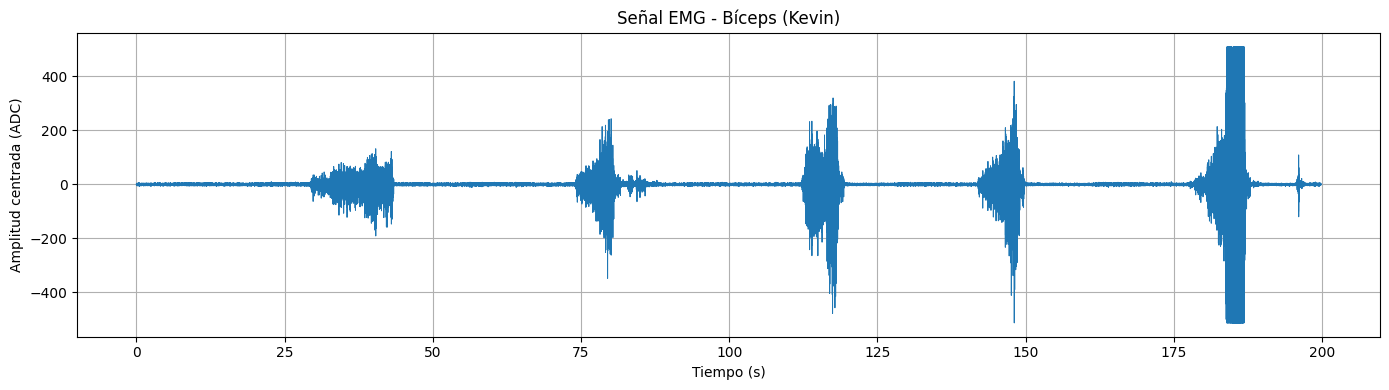

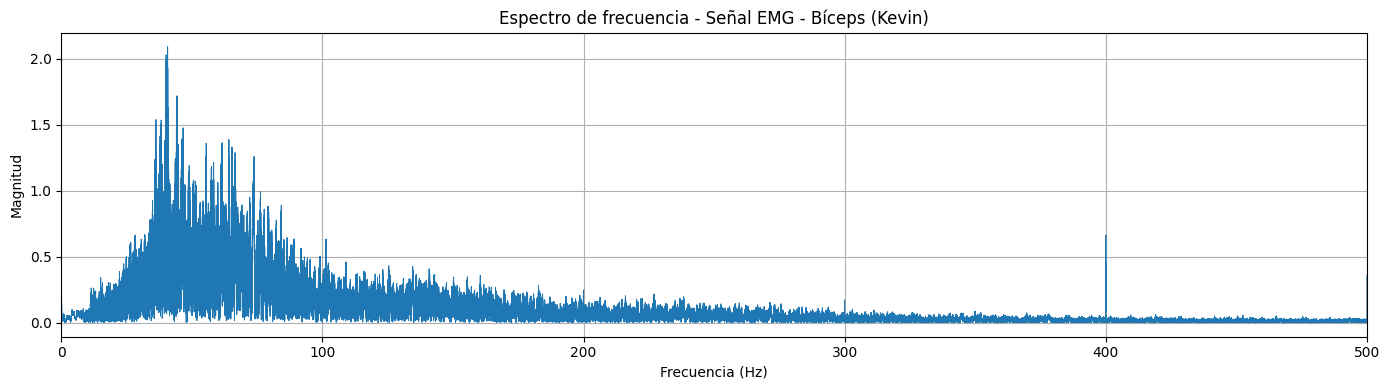

Duración: 199.8 s | Muestras: 199800 | Frecuencia de muestreo: 1000 Hz


In [5]:
plot_emg('biceps kevin.txt', 'Señal EMG - Bíceps (Kevin)')


## 5. Tríceps - Kevin

/tmp/ipykernel_2144/2963246686.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  datos = pd.read_csv(


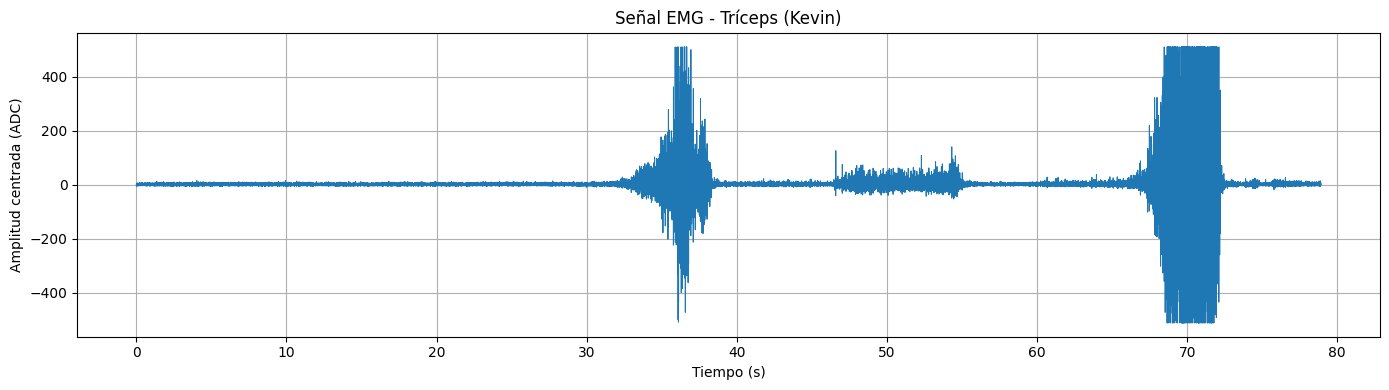

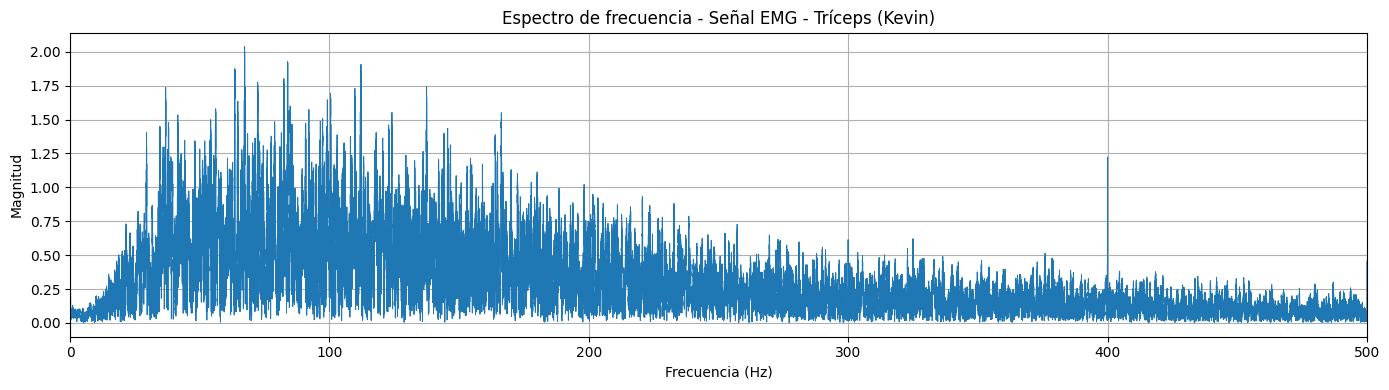

Duración: 78.9 s | Muestras: 78900 | Frecuencia de muestreo: 1000 Hz


In [6]:
plot_emg('triceps kevin.txt', 'Señal EMG - Tríceps (Kevin)')


## 6. Tríceps - Leo

/tmp/ipykernel_2144/2963246686.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  datos = pd.read_csv(


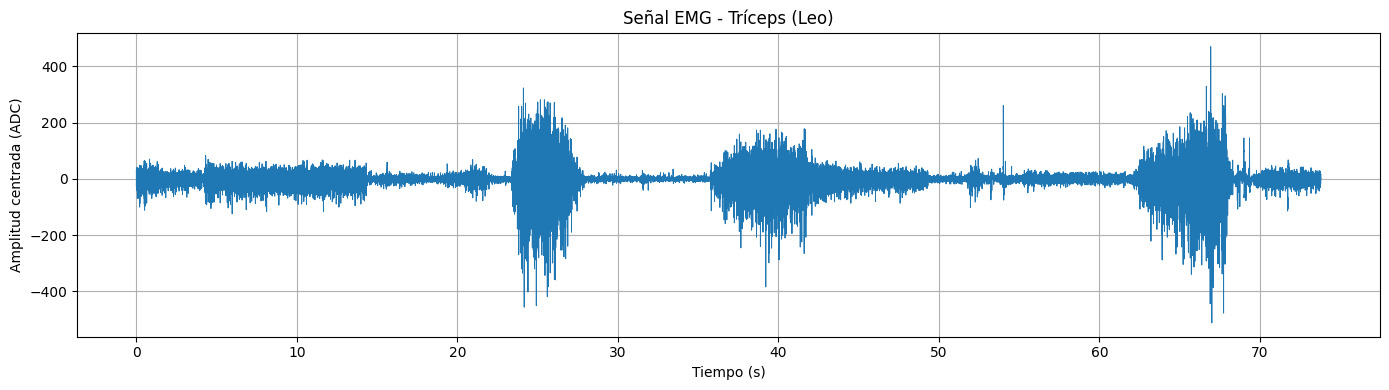

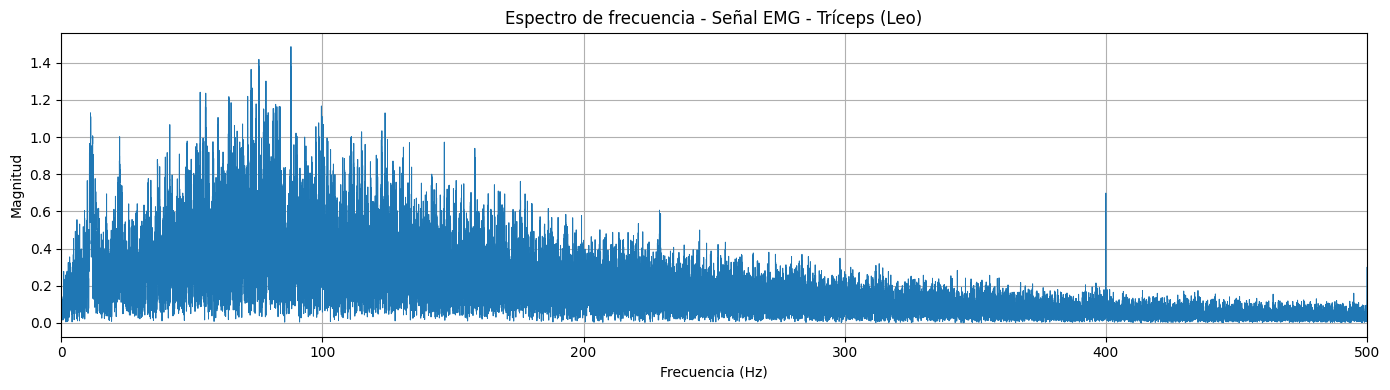

Duración: 73.8 s | Muestras: 73800 | Frecuencia de muestreo: 1000 Hz


In [7]:
plot_emg('triceps leo.txt', 'Señal EMG - Tríceps (Leo)')


## Interpretación

En el dominio del tiempo, los periodos con mayor variación de amplitud corresponden a una mayor actividad eléctrica muscular registrada por el sensor EMG. Los periodos con menor amplitud representan menor activación o reposo relativo.

El espectro de frecuencia, obtenido mediante la Transformada Rápida de Fourier (FFT), permite observar cómo se distribuye el contenido frecuencial de cada señal. Esta representación complementa el ploteo temporal y facilita la comparación entre las diferentes adquisiciones.